In [24]:
import numpy as np
import pathlib
from skimage import io, morphology
import pandas as pd
from tqdm import tqdm

import stackview 

In [20]:
dirname = pathlib.Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mTmG clones/05-29-2026 mTmG clone rep2/DOB 03-22-2026/F1 tail clip/R1/0. Day 0')

r_file = dirname / 'R_reg.tif'
height_file = dirname / 'height_image.tif'
heightmap_file = dirname / 'heightmap.tif'

R = io.imread(r_file)
height_image = io.imread(height_file)
# heightmap = io.imread(heightmap_file)
heightmap = np.argmax(height_image,axis=0)

/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_72032/2272873768.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(heightmap)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


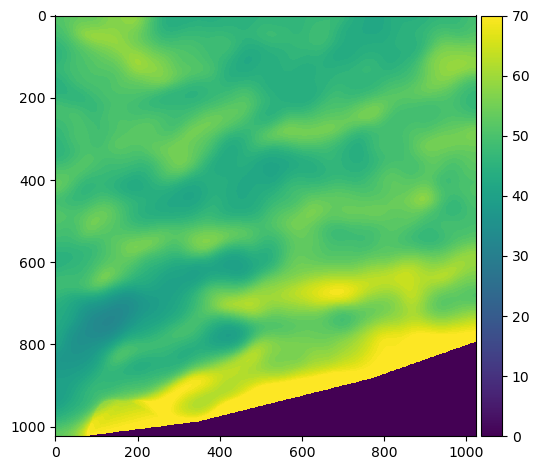

In [21]:
io.imshow(heightmap)

In [38]:
# Mask the R channel using height_image

def create_z_mask(map_2d, Z):
    """
    Create a 3D mask [Z, Y, X] where mask[z, y, x] = 1 if z > map_2d[y, x], else 0.

    Parameters:
        map_2d: np.ndarray of shape [Y, X], z-index values at each (y, x) location
        Z: int, size of the z-dimension for the output mask

    Returns:
        mask: np.ndarray of shape [Z, Y, X], dtype uint8 (or bool if you prefer)
    """
    map_2d = np.asarray(map_2d)
    Y, X = map_2d.shape

    # Column of z-indices: shape [Z, 1, 1], broadcasts against [Y, X]
    z_indices = np.arange(Z).reshape(Z, 1, 1)

    mask = (z_indices > map_2d[np.newaxis, :, :]).astype(bool)
    return mask

dermis_mask = create_z_mask(heightmap,R.shape[0])

In [39]:
stackview.orthogonal(dermis_mask,zoom_factor=0.5)

In [43]:
R_dermis = R.copy()
R_dermis[~dermis_mask] = 0
io.imsave(dirname / 'R_dermis.tif', R_dermis)

In [41]:
stackview.orthogonal(R_dermis,zoom_factor=0.5)

In [60]:
from imageUtils import reslice_by_heightmap

R_flat = reslice_by_heightmap(R,heightmap,top_border=-10,bottom_border=30)
io.imsave(dirname / 'R_flat.tif', R_flat)
stackview.orthogonal(R_flat,zoom_factor=0.4)